In [1]:
import cnsplots as cns
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from lifelines.datasets import load_waltons

cns.setup_matplotlib()
iris = sns.load_dataset("iris")
tips = sns.load_dataset("tips")
fmri = sns.load_dataset("fmri")
waltons = load_waltons()

de_results = pd.read_csv("DE_results.csv", index_col=0)

blobs = sc.datasets.blobs()
blobs.obs["mitf"] = np.random.random(blobs.shape[0])
blobs.var["ensemble"] = [f"ens{x}" for x in np.random.randint(0, 3, blobs.shape[1])]

Text(0, 0.5, 'ylabel')

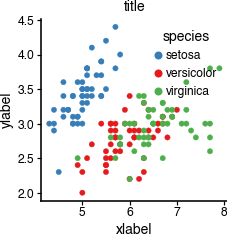

In [7]:
cns.figure(120, 120)
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", s=7, hue='species', edgecolor=None)
plt.title('title')
plt.xlabel('xlabel')
plt.ylabel('ylabel')
# plt.savefig('../../../Desktop/salam.pdf')

Boxplots represent the median and bottom and upper quartiles; whiskers correspond to 1.5 times the interquartile range.
setosa vs. versicolor: Mann-Whitney-Wilcoxon test two-sided, P_val:2.143e-13 U_stat=2.312e+03
versicolor vs. virginica: Mann-Whitney-Wilcoxon test two-sided, P_val:4.572e-03 U_stat=8.410e+02
setosa vs. virginica: Mann-Whitney-Wilcoxon test two-sided, P_val:7.100e-09 U_stat=2.086e+03
P values were determined by two-sided Mann-Whitney U test.


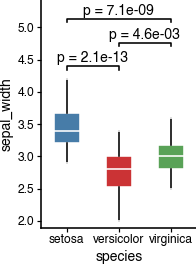

In [3]:
cns.figure(150, 100)
# cns.boxplot(data=tips, x="day", y="total_bill")
cns.boxplot(data=iris, x="species", y="sepal_width", pairs="all")
# plt.savefig('../../../Desktop/salam.pdf')

setosa vs. versicolor: Welch's t-test independent samples, P_val:2.484e-15 t=9.455e+00
versicolor vs. virginica: Welch's t-test independent samples, P_val:1.819e-03 t=-3.206e+00
setosa vs. virginica: Welch's t-test independent samples, P_val:4.571e-09 t=6.450e+00
P values were determined by two-sided Welch's t-test.


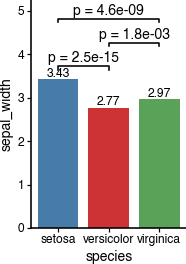

In [4]:
cns.figure(150, 100)
# cns.barplot(data=tips, x="day", y="total_bill", pairs="all", addtip=True)
cns.barplot(data=iris, x="species", y="sepal_width", pairs="all", addtip=True)
# plt.savefig('../../../Desktop/salam.pdf')

P values were determined by two-sided Fisher's exact test


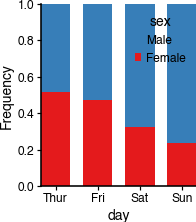

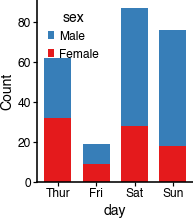

In [5]:
cns.figure(120, 100)
cns.stackplot(data=tips, x='day', hue='sex', normalize=True)
# plt.savefig('../../../Desktop/salam.pdf')
cns.figure(120, 100)
cns.stackplot(data=tips, x='day', hue='sex', normalize=False)
# plt.savefig('../../../Desktop/salam2.pdf')

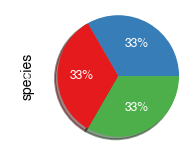

In [6]:
cns.figure(100, 100)
cns.piechart(iris, "species")
# plt.savefig('../../../Desktop/salam.pdf')

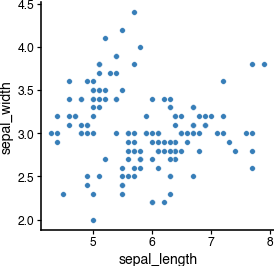

In [7]:
cns.figure(150, 150)
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", s=8)
# plt.savefig('../../../Desktop/salam.pdf')

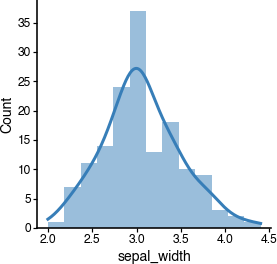

In [8]:
cns.figure(150, 150)
cns.distplot(data=iris, x="sepal_width")

<AxesSubplot: xlabel='sepal_length', ylabel='sepal_width'>

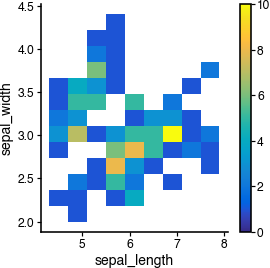

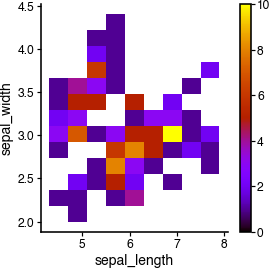

In [34]:
cns.figure(150, 150)
sns.histplot(data=iris, x="sepal_length", y="sepal_width", cbar=True, cmap='parula')
cns.figure(150, 150)
sns.histplot(data=iris, x="sepal_length", y="sepal_width", cbar=True, cmap='gnuplot')
# plt.savefig('../../../Desktop/salam.pdf')

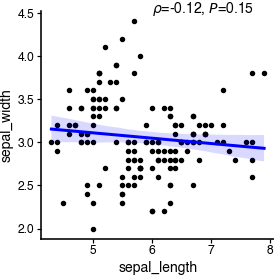

In [10]:
cns.figure(150, 150)
cns.regplot(data=iris, x="sepal_length", y="sepal_width")
# plt.savefig('../../../Desktop/salam.pdf')

P-value was determined by two-sided log-rank test.


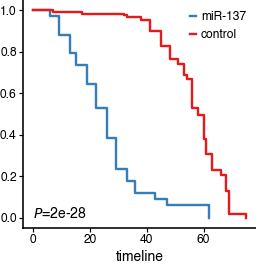

In [3]:
cns.figure(150, 150)
cns.survivalplot(data=waltons, duration="T", event="E", hue="group")
# plt.savefig('../../../Desktop/salam.pdf')

<AxesSubplot: xlabel='timepoint', ylabel='signal'>

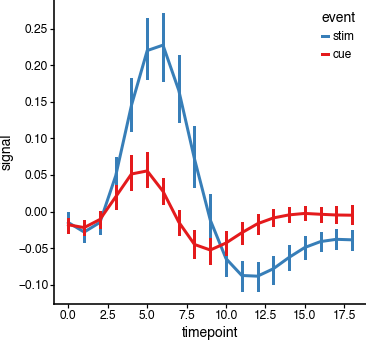

In [9]:
cns.figure(200, 200)
sns.lineplot(
    data=fmri, x="timepoint", y="signal", hue="event", err_style="bars",
)
# plt.savefig('../../../Desktop/salam.pdf')

{'matrix': <AxesSubplot: >,
 'shading': <AxesSubplot: >,
 'totals': <AxesSubplot: >,
 'intersections': <AxesSubplot: ylabel='Intersection size'>}

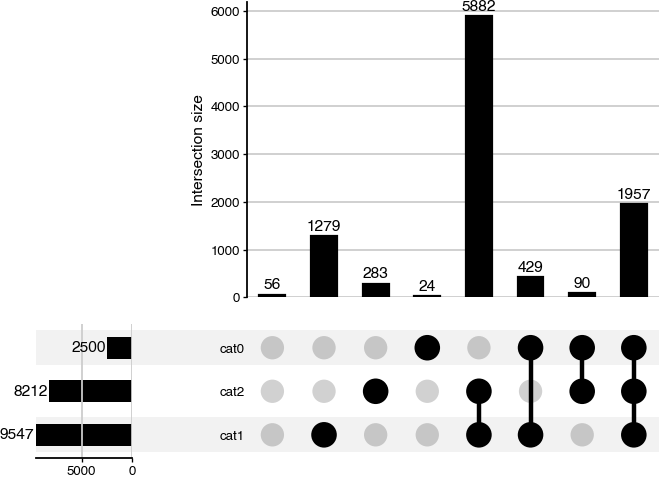

In [5]:
from upsetplot import generate_counts
from upsetplot import plot
example = generate_counts()
plot(example, element_size=30, show_counts=True)
# plt.savefig('../../../Desktop/salam.pdf')

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..


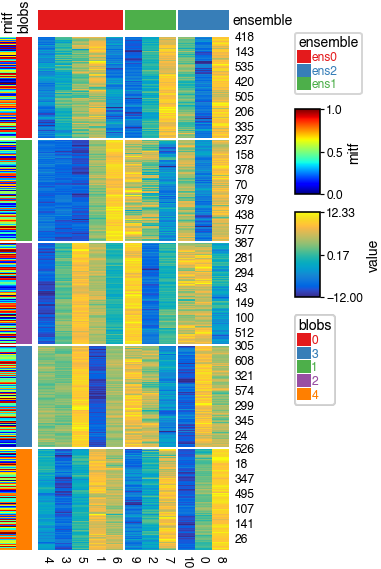

In [4]:
cns.figure(300, 150)
cns.heatmap(
    blobs,
    row_annotation=["mitf", "blobs"],
    col_annotation=["ensemble"],
    row_split="blobs",
    col_split=["ensemble"],
)
plt.savefig("../../../Desktop/salam.pdf")

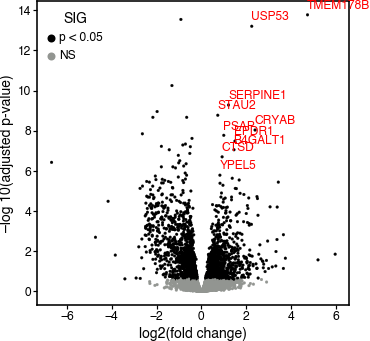

In [33]:
de_results["-log10(adjp)"] = -np.log10(de_results["padj"])
de_results["Rank"] = -np.log10(de_results.padj) * de_results["log2FoldChange"]
de_results['SIG'] = 'NS'
de_results['DEG'] = 'NS'
de_results.loc[(de_results['pvalue'] < 0.05), 'SIG'] = 'p < 0.05'
de_results.loc[(de_results['pvalue'] < 0.05) & (de_results['log2FoldChange'] > 0), 'DEG'] = 'Up'
de_results.loc[(de_results['pvalue'] < 0.05) & (de_results['log2FoldChange'] < 0), 'DEG'] = 'Down'

cns.figure(200, 200)
# https://github.com/DingWB/PyComplexHeatmap/blob/main/PyComplexHeatmap/bioinformatics_plot.py
ax = sns.scatterplot(
    data=de_results,
    x="log2FoldChange",
    y="-log10(adjp)",
    s=2,
    hue="SIG",
    edgecolor=None,
    palette=sns.xkcd_palette(["black", "grey"]),
)

for i, (x0, y0, t) in (
    de_results
    .loc[de_results["DEG"] == "Up", ["log2FoldChange", "-log10(adjp)", "symbol"]]
    .sort_values("-log10(adjp)", ascending=False)
    .head(10)
    .iterrows()
):
    ax.annotate(
        text=t,
        xy=(x0, y0),
        xytext=(-0.3, 3),
        annotation_clip=False,
        color="red",
        textcoords="offset points",
        size=6,
    )

ax.spines["right"].set_visible(True)
ax.spines["top"].set_visible(True)
plt.xlabel("log2(fold change)")
plt.ylabel("–log 10(adjusted p-value)")
plt.savefig("../../../Desktop/salam.pdf")


In [51]:
# https://github.com/krassowski/rpy2-complex-heatmap-grammar/blob/main/Examples.ipynb
# cns.heatmap(
#     adata_blobs,
#     row_colors=["blobs", "range"],
#     col_colors=["salam"],
#     cluster_rows=True,
#     cluster_columns=True,
#     show_row_names=False,
#     show_column_names=False,
# )

In [43]:
# from pycirclize import Circos
# import numpy as np
# np.random.seed(0)

# cns.figure(200, 200)
# sectors = {"A": 10, "B": 20, "C": 15}
# circos = Circos(sectors, space=10)
# for sector in circos.sectors:
#     # Plot heatmap 
#     track1 = sector.add_track((80, 100))
#     track1.axis()
#     track1.xticks_by_interval(1)
#     data = np.random.randint(0, 10, (4, int(sector.size)))
#     track1.heatmap(data, show_value=True)
#     # Plot heatmap with labels
#     track2 = sector.add_track((50, 70))
#     track2.axis()
#     x = np.linspace(1, int(track2.size), int(track2.size)) - 0.5
#     xlabels = [str(int(v + 1)) for v in x]
#     track2.xticks(x, xlabels, outer=False)
#     track2.yticks([0.5, 1.5, 2.5, 3.5, 4.5], list("ABCDE"), vmin=0, vmax=5)
#     data = np.random.randint(0, 100, (5, int(sector.size)))
#     track2.heatmap(data, cmap="viridis", rect_kws=dict(ec="white", lw=1))
# fig = circos.plotfig()
# plt.savefig('../../../Desktop/salam.pdf')